In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv(r"D:\NVIDIA AI Course\Udemy_NVIDIA-Certified_Associate_Generative_AI_LLMs_NCA-GENL_2025-1_Downloadly.ir\banking.csv")

In [6]:
data.shape

(41188, 21)

In [7]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [12]:
data['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [14]:
data['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [16]:
data['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

Text(0, 0.5, 'Freq of purchase')

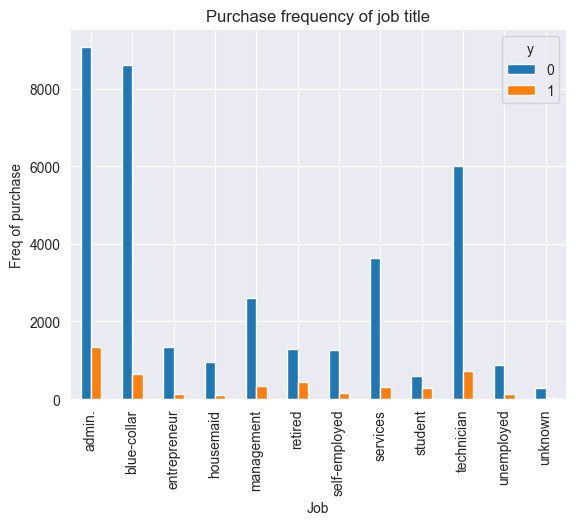

In [35]:
# crosstab function summarizes categorical data by showing how often each combination of values appears.
pd.crosstab(data['job'],data['y']).plot(kind = 'bar')
plt.title("Purchase frequency of job title")
plt.xlabel("Job")
plt.ylabel("Freq of purchase")

Text(0, 0.5, 'Freq of purchase')

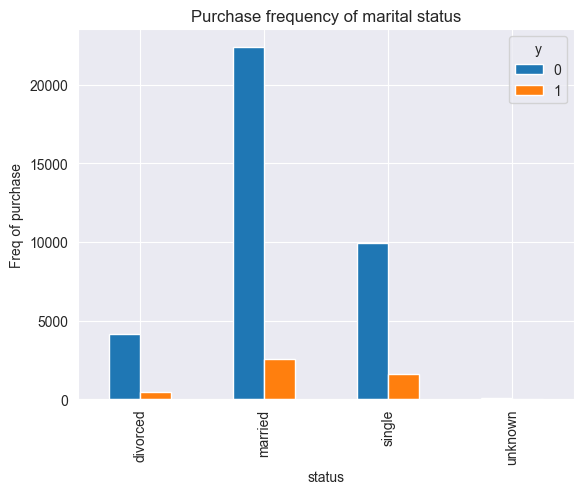

In [38]:
pd.crosstab(data['marital'],data['y']).plot(kind = 'bar')
plt.title("Purchase frequency of marital status")
plt.xlabel("status")
plt.ylabel("Freq of purchase")

Text(0, 0.5, 'Freq of purchase')

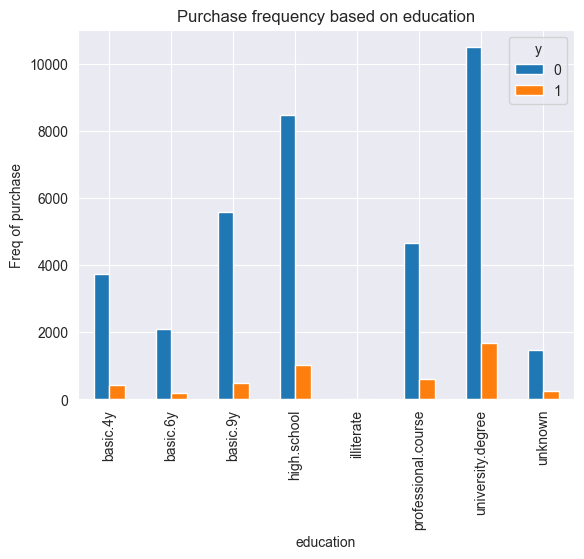

In [39]:
pd.crosstab(data['education'],data['y']).plot(kind = 'bar')
plt.title("Purchase frequency based on education")
plt.xlabel("education")
plt.ylabel("Freq of purchase")

In [41]:
# convert the data into numbers
# In pandas, get_dummies() is a function used to convert categorical variables (non-numeric data) into dummy/indicator variables (binary columns). This is essential for machine learning models, as most algorithms require numerical input.
data_final = pd.get_dummies(data,drop_first = True)
data_final.head()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,44,210,1,999,0,1.4,93.444,-36.1,4.963,5228.1,...,False,False,False,False,False,True,False,False,True,False
1,53,138,1,999,0,-0.1,93.200,-42.0,4.021,5195.8,...,False,True,False,False,False,False,False,False,True,False
2,28,339,3,6,2,-1.7,94.055,-39.8,0.729,4991.6,...,False,False,False,False,False,True,False,False,False,True
3,39,185,2,999,0,-1.8,93.075,-47.1,1.405,5099.1,...,False,False,False,False,False,False,False,False,True,False
4,55,137,1,3,1,-2.9,92.201,-31.4,0.869,5076.2,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
X = data_final.drop(column='y')
y = data_final['y']